In [1]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# conectar con MySQL utilizando sqlalchemy
from sqlalchemy import create_engine

host = '212.227.90.6'
database = 'Equip_18'
user = 'Equipo18'
password = 'E1q2u3i4p5o18'

# crear la engine para la conexión
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

# conectar con la BBDD
connection = engine.connect()

# cargar la tabla BANK_marketing como un df
df = pd.read_sql_table('BANK_marketing10112025', connection)

connection.close()

In [3]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26187 entries, 0 to 26186
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         26187 non-null  int64  
 1   age        26166 non-null  float64
 2   job        26187 non-null  object 
 3   marital    26175 non-null  object 
 4   education  26167 non-null  object 
 5   default    26172 non-null  object 
 6   balance    26187 non-null  int64  
 7   housing    26111 non-null  object 
 8   loan       26187 non-null  object 
 9   contact    26187 non-null  object 
 10  day        26187 non-null  int64  
 11  month      26187 non-null  object 
 12  duration   26187 non-null  int64  
 13  campaign   26187 non-null  int64  
 14  pdays      26187 non-null  int64  
 15  previous   26187 non-null  int64  
 16  poutcome   26187 non-null  object 
 17  deposit    26187 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 3.6+ MB


In [5]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,26187.000000,26166.000000,26187.000000,26187.000000,26187.000000,26187.000000,26187.000000,26187.000000
mean,13164.467140,41.322059,1529.374270,15.659602,370.638256,2.526024,51.342155,0.839730
std,7642.285369,11.929372,3302.494077,8.449240,347.712052,2.789046,109.586224,2.316597
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,6538.500000,32.000000,123.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,13083.000000,39.000000,553.000000,15.000000,253.000000,2.000000,-1.000000,0.000000
75%,19838.500000,49.000000,1710.500000,22.000000,494.000000,3.000000,9.000000,1.000000
max,26383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.describe(include=object)

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,26187,26175,26167,26172,26111,26187,26187,26187,26187,26187
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,6009,14881,12785,25778,13858,22741,18795,6625,19583,13850


               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.115229  0.003905  0.002034 -0.005492 -0.000549  0.021058
balance   0.115229  1.000000  0.011973  0.015954 -0.018333  0.015219  0.025258
day       0.003905  0.011973  1.000000 -0.020899  0.138792 -0.085648 -0.063991
duration  0.002034  0.015954 -0.020899  1.000000 -0.050079 -0.029411 -0.027526
campaign -0.005492 -0.018333  0.138792 -0.050079  1.000000 -0.104386 -0.053988
pdays    -0.000549  0.015219 -0.085648 -0.029411 -0.104386  1.000000  0.511044
previous  0.021058  0.025258 -0.063991 -0.027526 -0.053988  0.511044  1.000000


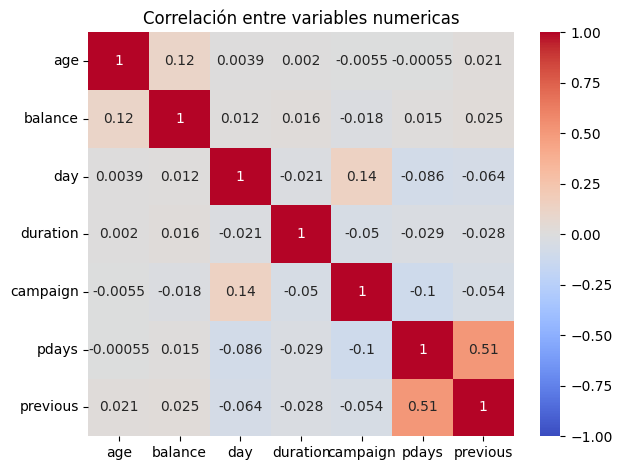

In [7]:
df_varnumericas=df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']] 
correlation = df_varnumericas.corr() #saco la correlacion
print(correlation)

sns.heatmap(correlation,
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1)      # aca defino la escala de correlacion

plt.title('Correlación entre variables numericas', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# crear variables con columnas numéricas o categóricas
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

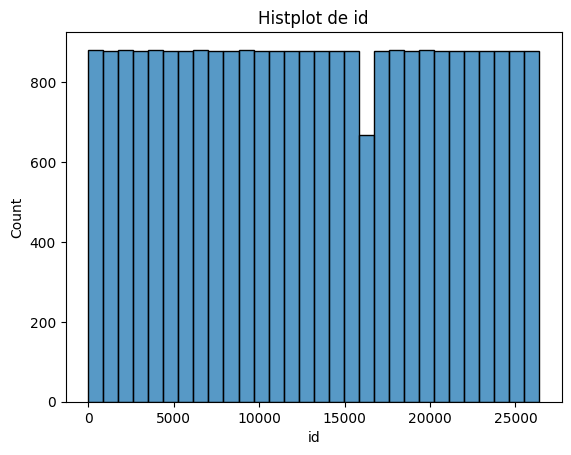

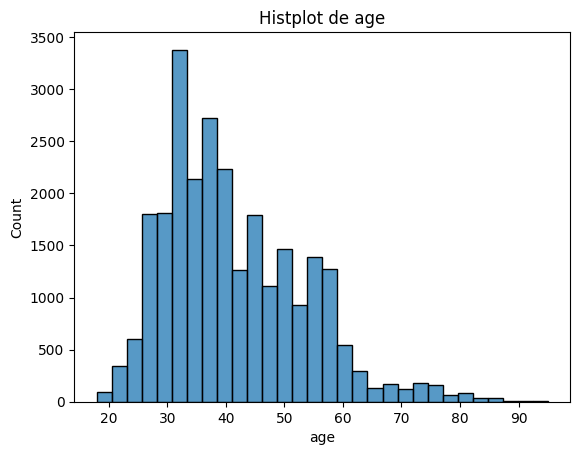

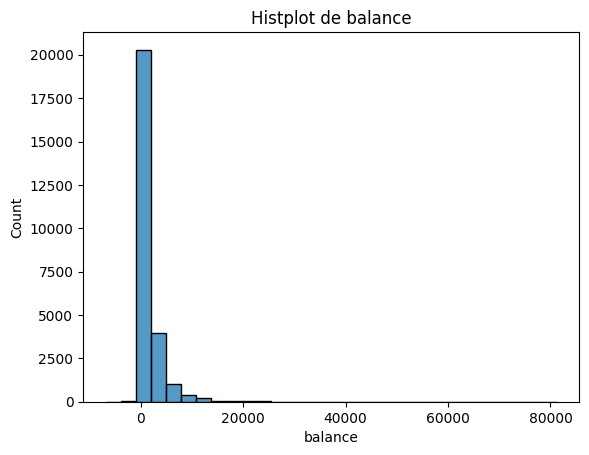

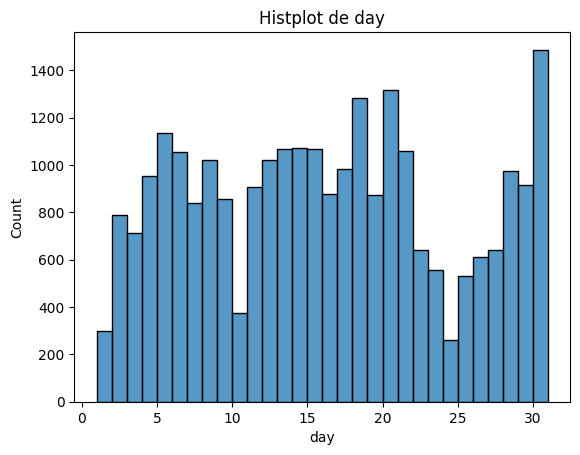

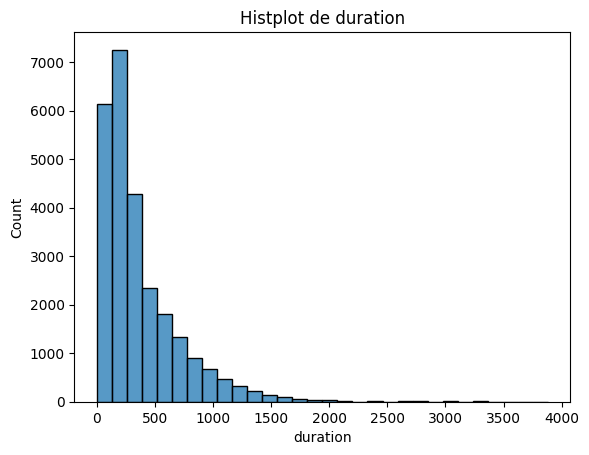

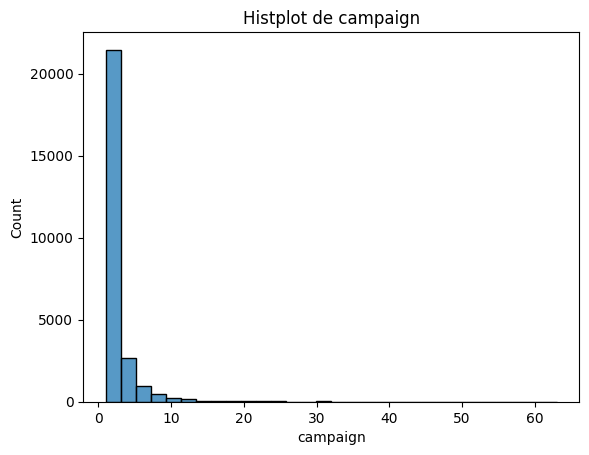

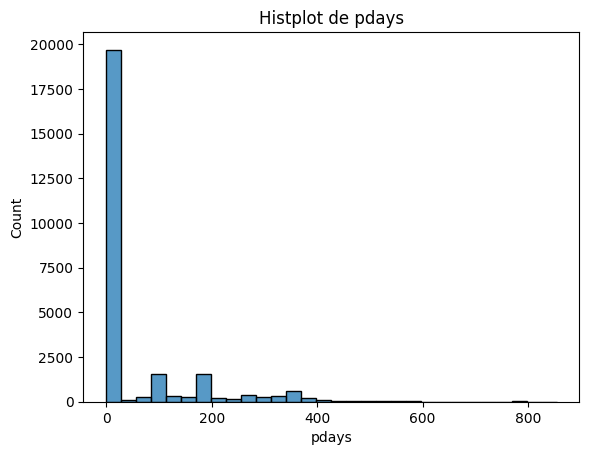

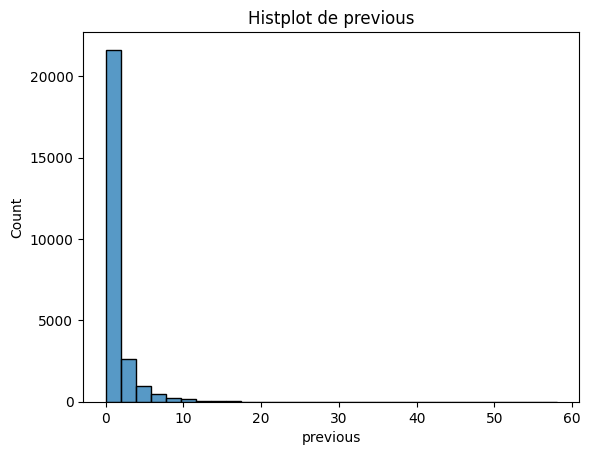

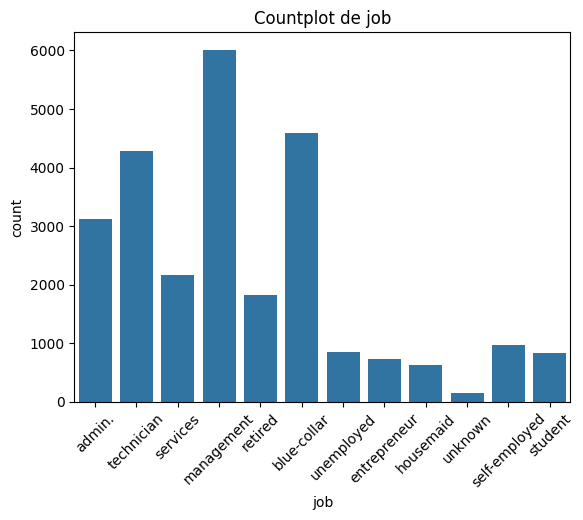

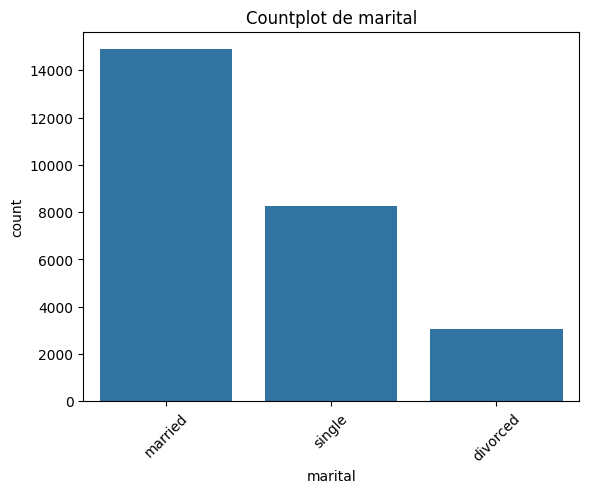

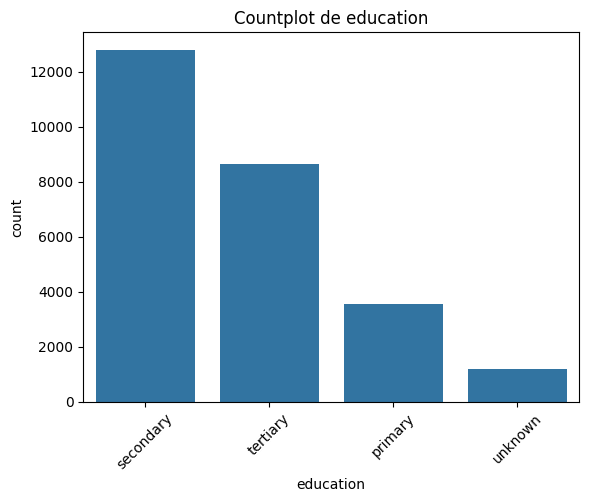

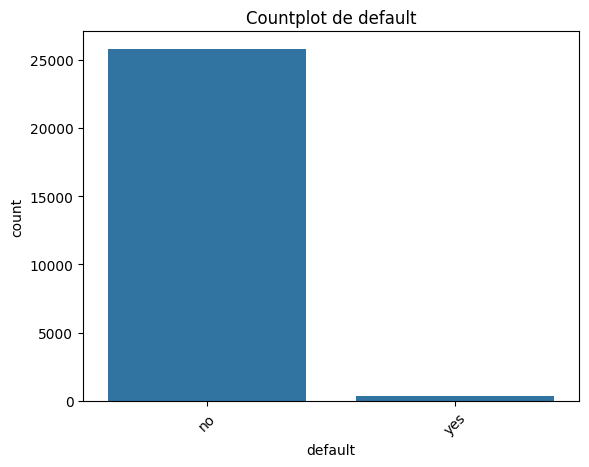

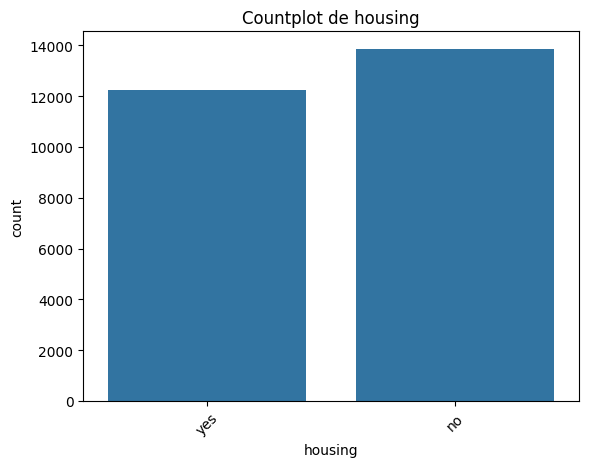

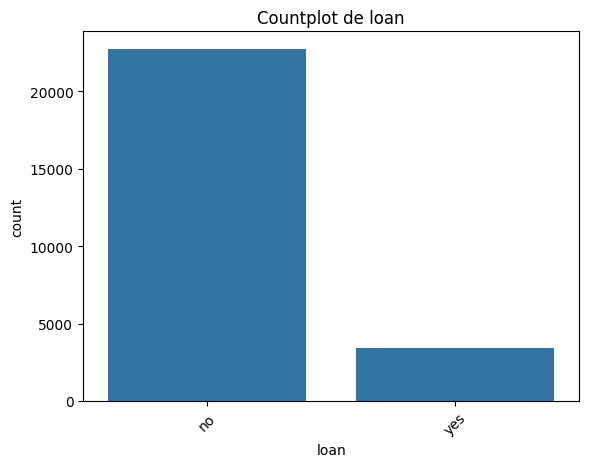

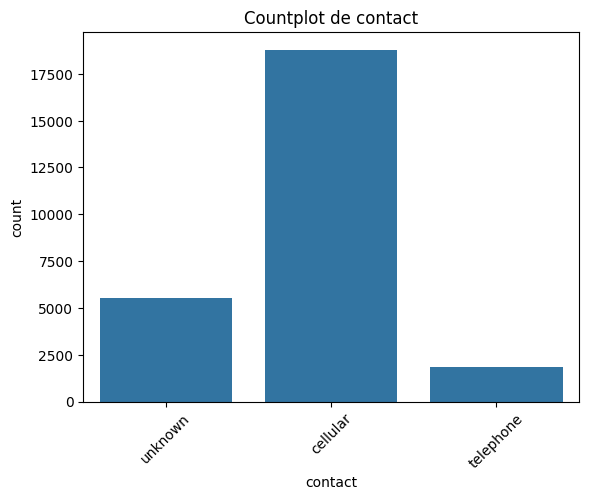

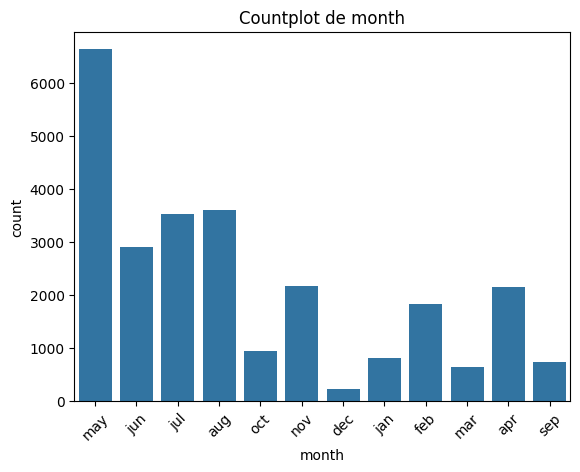

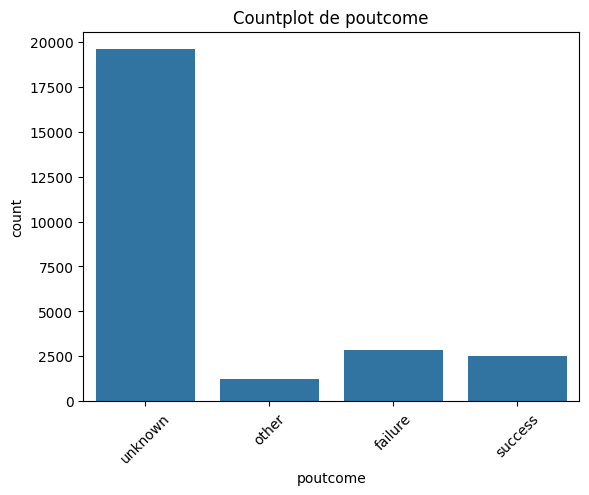

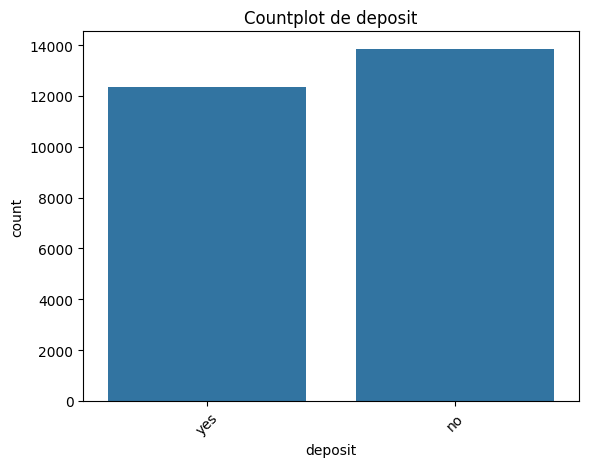

In [9]:
# hacer histplots de las columnas numéricas
for columna in num_cols:
    sns.histplot(data=df, x = columna, bins=30)
    plt.title(f'Histplot de {columna}')
    plt.show()

# hacer countplots de las columnas categóricas
for columna in cat_cols:
    sns.countplot(data=df, x=columna)
    plt.title(f'Countplot de {columna}')
    plt.xticks(rotation=45)
    plt.show()